In [4]:
import pandas as pd


df = pd.read_csv('data/combined_urban_features.csv')
df


# TO DO HERE CORRELATION AND CHECK HOW OUR FAETURES AND WORKING TOGETHER

,city_name,grid_id,target_style,building_count,building_density,avg_building_area,avg_building_perimeter,shape_complexity_ratio,courtyard_index,road_segment_count,total_road_length,avg_road_segment_length,road_density_ratio
0,"Copenhagen Municipality, Denmark",203,XIX_Century_Blocks,79,0.309089,626.003731,133.497337,0.484876,0.909601,413,15207.553658,36.822164,0.027158
1,"Copenhagen Municipality, Denmark",204,XIX_Century_Blocks,72,0.402768,895.040229,188.142695,0.442850,0.852785,193,11971.120615,62.026532,0.016122
2,"Copenhagen Municipality, Denmark",205,XIX_Century_Blocks,84,0.321603,612.577809,134.851120,0.342384,0.851486,241,12330.557734,51.164140,0.019545
3,"Copenhagen Municipality, Denmark",226,XIX_Century_Blocks,55,0.178457,519.148214,117.504043,0.437926,0.912516,118,8290.188075,70.255831,0.014234
4,"Copenhagen Municipality, Denmark",227,XIX_Century_Blocks,120,0.476144,634.858359,133.401019,0.448295,0.863188,227,11363.789387,50.060746,0.019976
...,...,...,...,...,...,...,...,...,...,...,...,...,...
105,"Aarhus Kommune, Denmark",2502,Modern_Urbanism,37,0.273667,1183.425742,189.781298,0.303800,0.828280,364,13665.217904,37.541807,0.026637
106,"Aarhus Kommune, Denmark",2503,Medieval_Center,5,0.093402,2988.867290,388.656808,0.130342,0.706091,108,3691.173188,34.177530,0.029259
107,"Aarhus Kommune, Denmark",2504,Medieval_Center,0,0.000000,0.000000,0.000000,0.000000,0.000000,12,4219.938425,351.661535,0.002844
108,"Aarhus Kommune, Denmark",2581,Modern_Urbanism,0,0.000000,0.000000,0.000000,0.000000,0.000000,0,0.000000,0.000000,0.000000


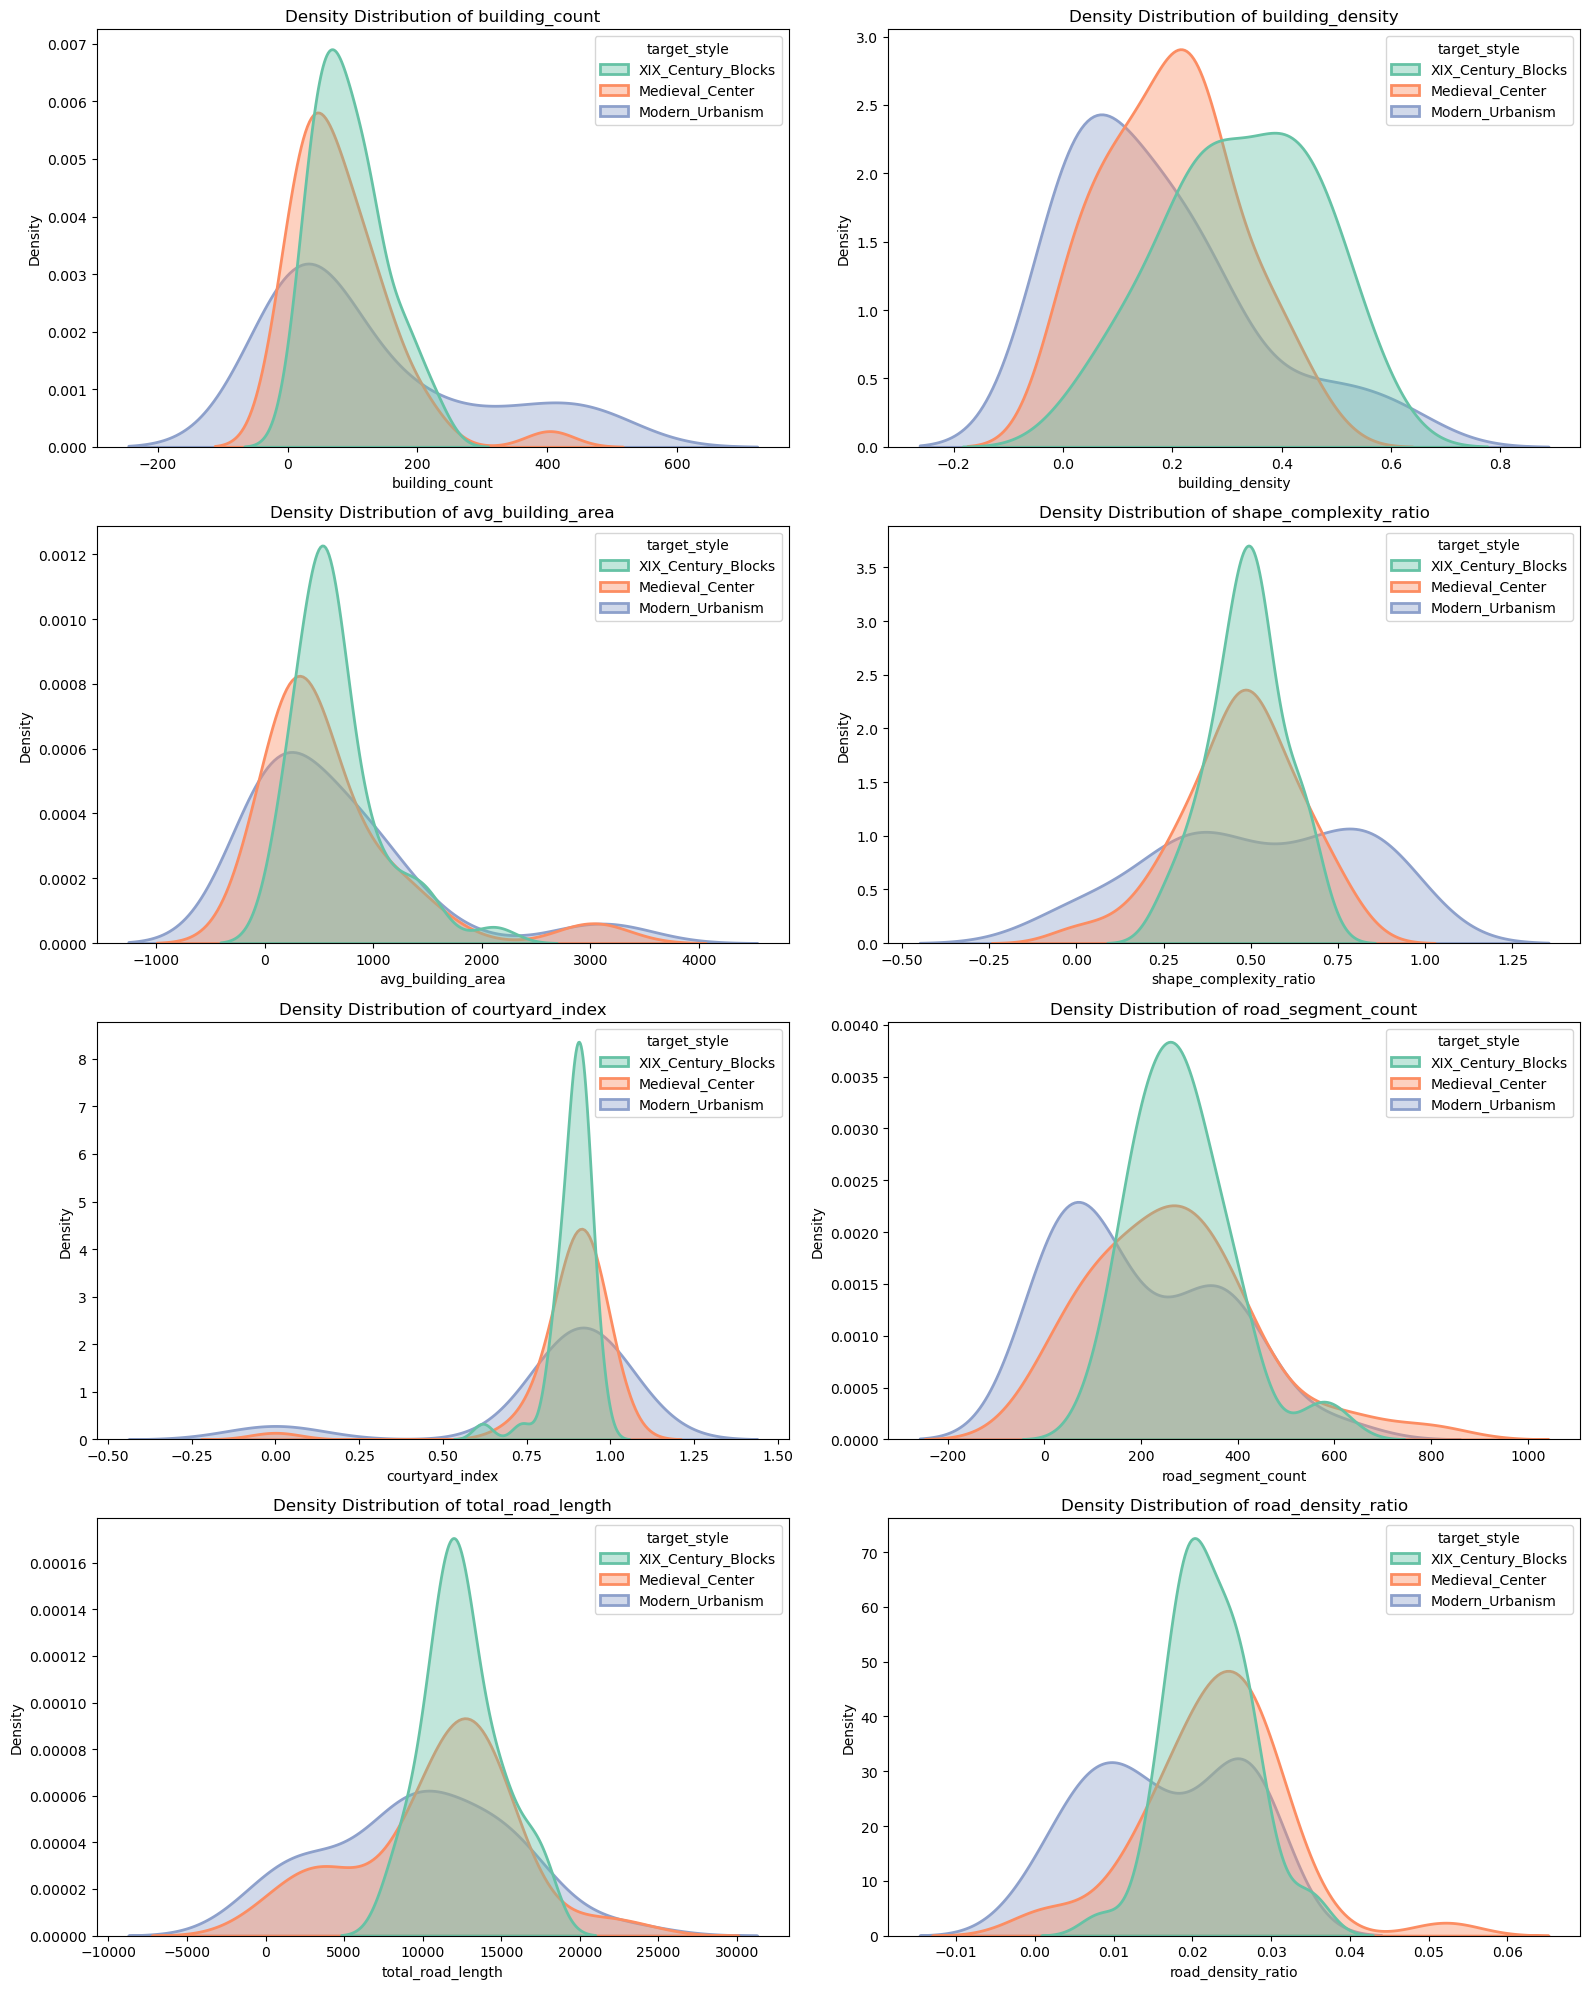

In [9]:
import matplotlib.pyplot as plt 
import seaborn as sns
feature_cols = [
    'building_count', 'building_density', 'avg_building_area', 
    'shape_complexity_ratio', 'courtyard_index', 
    'road_segment_count', 'total_road_length', 'road_density_ratio'
]


fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(16, 20))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    sns.kdeplot(
        data=df,
        x=col,
        hue='target_style',
        fill=True,
        common_norm=False,  # Uniezależnia wykres od różnic w liczebności klas
        alpha=0.4,
        linewidth=2,
        palette='Set2',
        ax=axes[i]
    )
    axes[i].set_title(f"Density Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Density")

plt.tight_layout()
plt.show()

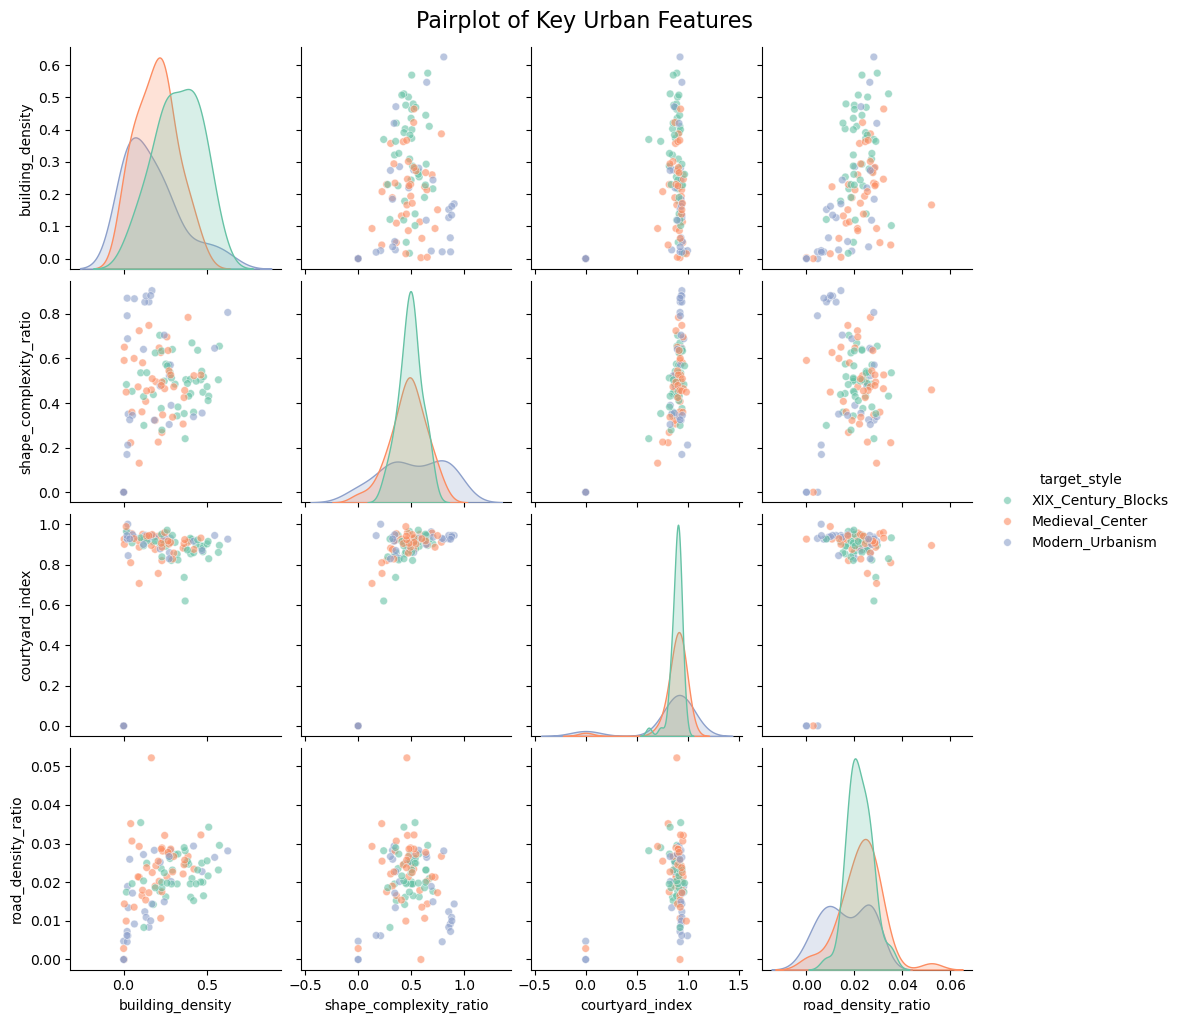

In [ ]:

selected_features = ['building_density', 'shape_complexity_ratio', 'courtyard_index', 'road_density_ratio', 'target_style']


sns.pairplot(
    df[selected_features], 
    hue='target_style', 
    palette='Set2', 
    diag_kind='kde',
    plot_kws={'alpha': 0.6, 's': 30}
)
plt.suptitle("Pairplot of Key Urban Features", y=1.02, fontsize=16)
plt.show()

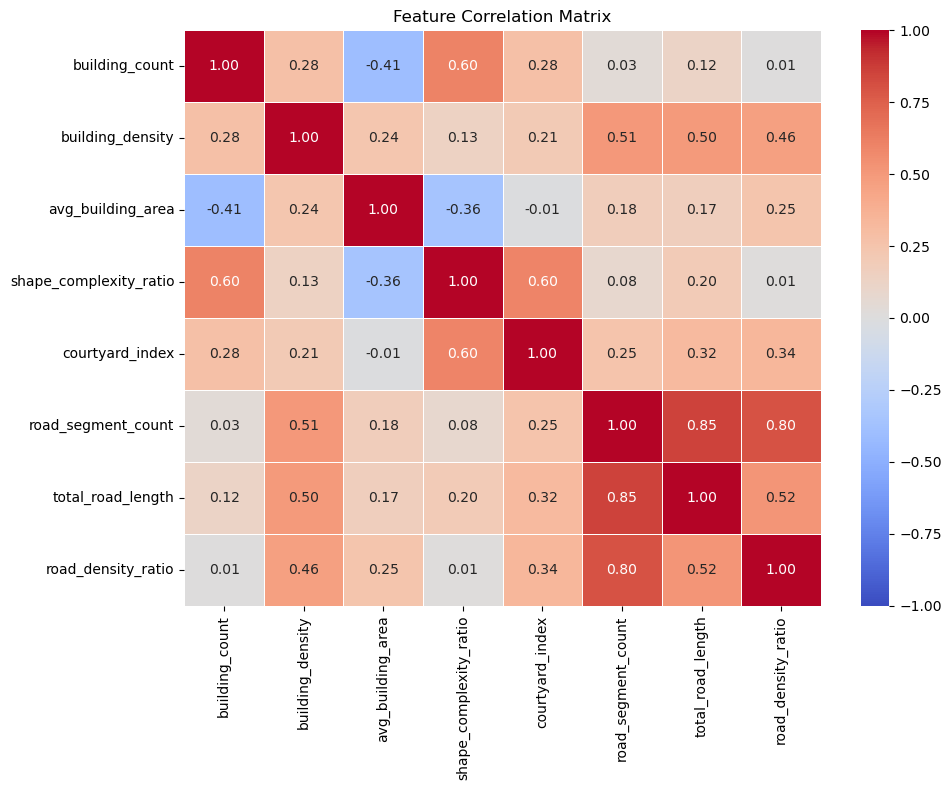

In [7]:
plt.figsize = (10, 8)

corr_matrix = df[feature_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    cmap='coolwarm', 
    fmt=".2f", 
    linewidths=0.5,
    vmin=-1, vmax=1
)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

Number of samples per class:
target_style
XIX_Century_Blocks    42
Medieval_Center       39
Modern_Urbanism       29
Name: count, dtype: int64

Percentage share per class:
target_style
XIX_Century_Blocks    38.181818
Medieval_Center       35.454545
Modern_Urbanism       26.363636
Name: proportion, dtype: float64


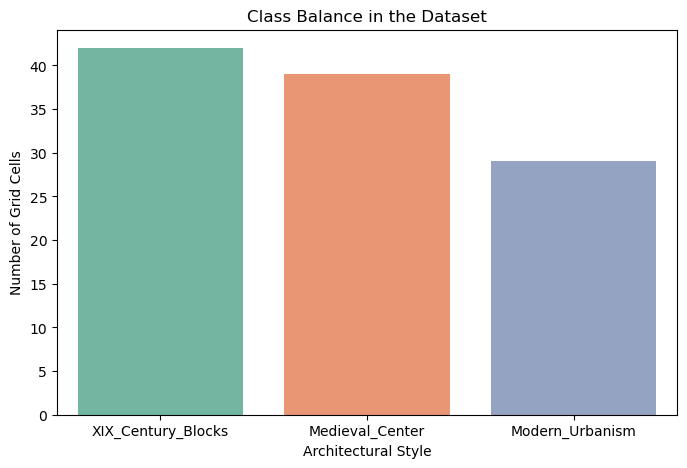

In [8]:
print("Number of samples per class:")
print(df['target_style'].value_counts())

print("\nPercentage share per class:")
print(df['target_style'].value_counts(normalize=True) * 100)

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='target_style', palette='Set2', hue='target_style', legend=False)
plt.title("Class Balance in the Dataset")
plt.ylabel("Number of Grid Cells")
plt.xlabel("Architectural Style")
plt.show()